In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [11]:
train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

# Zkusíme si vypsat hlavičku (uvidíš sloupec 'label' a 784 sloupců s pixely)
print("Tvar tabulky:", train_df.shape) # Mělo by to být (42000, 785)
display(train_df.head())

Tvar tabulky: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


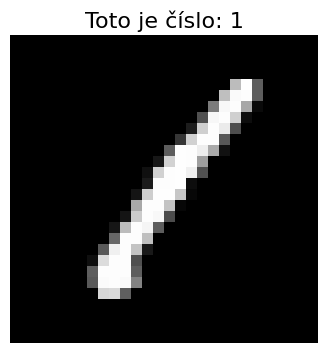

In [12]:
# display single image:
single_line = train_df.iloc[0]
#print(single_line)

label = single_line['label']
pixels = single_line.drop('label').values 

image = pixels.reshape(28,28)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray') 
plt.title(f"Toto je číslo: {label}", fontsize=16)
plt.axis('off') 
plt.show()



In [13]:
# uneficient KNN algorithm, just to see the issue with 784 dimension
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

df_subset = train_df.iloc[:10000]

y = df_subset['label']
x = df_subset.drop('label', axis=1)

# color normalization, alhtough it already shall be between 0-1
x=x/255.0

x_train, x_val, y_train, y_val = train_test_split(x,y,test_size=0.2,random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_train, y_train)

y_pred = knn.predict(x_val)

acc = accuracy_score(y_val, y_pred) *100
print(f"\n✅ Hotovo! Přesnost KNN na MNISTu: {acc:.2f} %")


✅ Hotovo! Přesnost KNN na MNISTu: 95.10 %


Původní počet pixelů: 784. Počet HOG příznaků po extrakci: 1296
✅ Přesnost HOG + SVM na MNISTu: 98.69 %


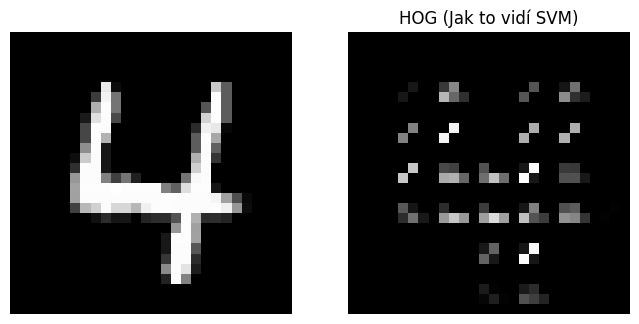

In [14]:
# HOG + SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from skimage.feature import hog

train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

df_subset = train_df
y = df_subset['label'].values
x_raw = df_subset.drop('label', axis=1).values

x_images = x_raw.reshape(-1,28,28)

hog_features = []
for img in x_images:
    features = hog(img, orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2), visualize=False)
    hog_features.append(features)


x_hog = np.array(hog_features)
print(f"Původní počet pixelů: 784. Počet HOG příznaků po extrakci: {x_hog.shape[1]}")

x_train, x_val, y_train, y_val = train_test_split(x_hog, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', C=10)
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_val)
acc = accuracy_score(y_val,y_pred) *100
print(f"✅ Přesnost HOG + SVM na MNISTu: {acc:.2f} %")

# HOG vizualization:
img = x_images[42]
label = y[42]

_, hog_img = hog(img,  orientations=9, pixels_per_cell=(4, 4), 
                     cells_per_block=(2, 2), visualize=True)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
# Zvýraznění HOG obrázku pro lepší vizualizaci
plt.imshow(hog_img, cmap='gray')
plt.title("HOG (Jak to vidí SVM)")
plt.axis('off')
plt.show()

In [15]:
# CNN
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
import torchmetrics
import warnings

# Skryjeme otravná varování, ať máme čistý výstup
warnings.filterwarnings("ignore")
# Potlačíme i to konkrétní varování z PyTorch Lightning ohledně num_workers
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

df_subset = train_df

# Oddělíme labels a pixely
y = df_subset['label'].values
X = df_subset.drop('label', axis=1).values

X = X / 255.0

X_reshaped = X.reshape(-1, 1, 28, 28)
X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.long))

val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                            torch.tensor(y_val, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
class LitDigitCNN(pl.LightningModule):
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        
        # Metrika pro měření přesnosti (pro více tříd -> task="multiclass", num_classes=10)
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        
        # --- DEFINICE VRSTEV (Architektura CNN) ---
        self.conv_layers = nn.Sequential(
            # 1. Konvoluce: Vstup má 1 kanál (černobílý). Síť najde 16 různých "filtrů" (hran, rohů).
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            # MaxPool zmenší obrázek z 28x28 na 14x14
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # 2. Konvoluce: Z 16 filtrů najde 32 složitějších tvarů.
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            # MaxPool zmenší obrázek z 14x14 na 7x7
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # --- DEFINICE KLASIFIKÁTORU (Na konci obrázek zploštíme do nudle) ---
        # Po dvou MaxPoolingách se nám z 28x28 stalo 7x7. Máme 32 kanálů.
        # Takže 32 * 7 * 7 = 1568 "zploštělých" pixelů
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Prevence overfittingu (občas "vypne" některé neurony)
            nn.Linear(128, 10)  # Výstup je 10 čísel (pravděpodobnost pro číslice 0 až 9)
        )
        
        # Ztrátová funkce pro kategorizaci do více tříd
        self.criterion = nn.CrossEntropyLoss()

    # Zde definujeme, jak data tečou skrze vrstvy
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.linear_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x) # Získáme 10 predikcí pro každý obrázek
        loss = self.criterion(logits, y) # Spočítáme chybu
        
        # Logování (můžeme pak vidět grafy)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        
        # Vypočítáme přesnost. argmax() vybere to z 10 čísel, které je největší
        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, y)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)


# =====================================================================
# 3. SPUŠTĚNÍ TRÉNINKU
# =====================================================================
print("\nZačínám trénink (PyTorch Lightning)...")

# Inicializace modelu
model = LitDigitCNN()

# Založení Lightning Traineru
# Vybereme auto pro 'accelerator', pokud máš zapnuté GPU na Kaggle, najde si ho samo!
#trainer = pl.Trainer(max_epochs=50, accelerator='auto', enable_progress_bar=True)

# Start!
#trainer.fit(model, train_loader, val_loader)

print("✅ Trénink dokončen!")



Začínám trénink (PyTorch Lightning)...
✅ Trénink dokončen!


In [16]:
# =====================================================================
# INFERENCE NA TESTOVACÍCH DATECH PRO KAGGLE (NEW)
# =====================================================================
#print("\n3. Načítám a připravuji TESTOVACÍ data pro Kaggle...")
#test_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

# Test data nemají sloupec 'label', takže vezmeme rovnou všechno jako pixely
#X_test = test_df.values

# Musíme to upravit ÚPLNĚ STEJNĚ jako trénovací data!
#X_test = X_test / 255.0  # Normalizace
#X_test_reshaped = X_test.reshape(-1, 1, 28, 28) # Převedení z nudle na obrázky

# Převedeme numpy pole na PyTorch Tensor
#tensor_X_test = torch.tensor(X_test_reshaped, dtype=torch.float32)

print("4. Predikuji čísla na testovací sadě...")
#model.eval() # Přepneme síť do módu hodnocení (vypne Dropout atd.)

#with torch.no_grad(): # Zastavíme ukládání gradientů do paměti (potřebujeme to jen počítat, ne se učit)
#    # Pošleme všechna data do sítě naráz (nebo po dávkách, pokud jich je hodně, ale u MNISTu se to vejde do RAM)
 #   test_logits = model(tensor_X_test)
    
    # Vybereme ten neuron z 10, který křičí nejvíc (největší pravděpodobnost)
 #   final_predictions = torch.argmax(test_logits, dim=1).numpy()

# 5. ULOŽENÍ DO KAGGLE FORMÁTU
print("5. Ukládám výsledky do souboru 'submission.csv'...")

# Kaggle chce sloupce ImageId (1 až N) a Label
#image_ids = np.arange(1, len(final_predictions) + 1)
#output = pd.DataFrame({'ImageId': image_ids, 'Label': final_predictions})

#output.to_csv('submission1.csv', index=False)
print("🏆 Hotovo! Soubor submission.csv je připraven k odeslání. Odevzdej ho v pravém panelu pod 'Output' -> 'Submit to competition'.")

4. Predikuji čísla na testovací sadě...
5. Ukládám výsledky do souboru 'submission.csv'...
🏆 Hotovo! Soubor submission.csv je připraven k odeslání. Odevzdej ho v pravém panelu pod 'Output' -> 'Submit to competition'.


In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping # <-- IMPORT EARLY STOPPING
import torchmetrics
import warnings

# Skryjeme otravná varování
warnings.filterwarnings("ignore")
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

print("1. Načítám data...")
train_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df_subset = train_df # Používáme celá data

y = df_subset['label'].values
X = df_subset.drop('label', axis=1).values
X = X / 255.0
X_reshaped = X.reshape(-1, 1, 28, 28)

X_train, X_val, y_train, y_val = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train, dtype=torch.long))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), 
                            torch.tensor(y_val, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# =====================================================================
# DEFINICE MODELU
# =====================================================================
class LitDigitCNN(pl.LightningModule):
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        self.learning_rate = learning_rate
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10)
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 10)
        )
        
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.linear_layers(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        preds = torch.argmax(logits, dim=1)
        acc = self.accuracy(preds, y)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.learning_rate)


# =====================================================================
# SPUŠTĚNÍ TRÉNINKU S EARLY STOPPINGEM
# =====================================================================
print("\n2. Začínám trénink s Early Stopping...")

model = LitDigitCNN()

# Nastavení Early Stoppingu
# Zastaví trénink, pokud se 'val_loss' nezlepší o minimálně 0.001 po dobu 10 epoch
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=50, 
    verbose=True,
    mode='min'
)

# Trainer dostane max_epochs=500, ale Early Stopping to utne dřív!
trainer = pl.Trainer(
    max_epochs=500, 
    accelerator='auto', 
    enable_progress_bar=True,
    callbacks=[early_stop_callback] # ZDE PŘIDÁNO!
)

trainer.fit(model, train_loader, val_loader)

print("✅ Trénink dokončen!")

1. Načítám data...

2. Začínám trénink s Early Stopping...


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ accuracy      │ MulticlassAccuracy │      0 │ train │     0 │
│ 1 │ conv_layers   │ Sequential         │  4.8 K │ train │     0 │
│ 2 │ linear_layers │ Sequential         │  202 K │ train │     0 │
│ 3 │ criterion     │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 206 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 206 K                                                                                                
Total estimated model params size (MB): 0.828                                                                      
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

✅ Trénink dokončen!


In [18]:
# =====================================================================
# INFERENCE NA TESTOVACÍCH DATECH PRO KAGGLE (NEW)
# =====================================================================
print("\n3. Načítám a připravuji TESTOVACÍ data pro Kaggle...")
test_df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')

# Test data nemají sloupec 'label', takže vezmeme rovnou všechno jako pixely
X_test = test_df.values

# Musíme to upravit ÚPLNĚ STEJNĚ jako trénovací data!
X_test = X_test / 255.0  # Normalizace
X_test_reshaped = X_test.reshape(-1, 1, 28, 28) # Převedení z nudle na obrázky

# Převedeme numpy pole na PyTorch Tensor
tensor_X_test = torch.tensor(X_test_reshaped, dtype=torch.float32)

print("4. Predikuji čísla na testovací sadě...")
model.eval() # Přepneme síť do módu hodnocení (vypne Dropout atd.)

with torch.no_grad(): # Zastavíme ukládání gradientů do paměti (potřebujeme to jen počítat, ne se učit)
    # Pošleme všechna data do sítě naráz (nebo po dávkách, pokud jich je hodně, ale u MNISTu se to vejde do RAM)
    test_logits = model(tensor_X_test)
    
    # Vybereme ten neuron z 10, který křičí nejvíc (největší pravděpodobnost)
    final_predictions = torch.argmax(test_logits, dim=1).numpy()

# 5. ULOŽENÍ DO KAGGLE FORMÁTU
print("5. Ukládám výsledky do souboru 'submission.csv'...")

# Kaggle chce sloupce ImageId (1 až N) a Label
image_ids = np.arange(1, len(final_predictions) + 1)
output = pd.DataFrame({'ImageId': image_ids, 'Label': final_predictions})

output.to_csv('submission.csv', index=False)
print("🏆 Hotovo! Soubor submission.csv je připraven k odeslání. Odevzdej ho v pravém panelu pod 'Output' -> 'Submit to competition'.")


3. Načítám a připravuji TESTOVACÍ data pro Kaggle...
4. Predikuji čísla na testovací sadě...
5. Ukládám výsledky do souboru 'submission.csv'...
🏆 Hotovo! Soubor submission.csv je připraven k odeslání. Odevzdej ho v pravém panelu pod 'Output' -> 'Submit to competition'.
